In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [3]:
data = load_breast_cancer()
X=pd.DataFrame(data.data, columns=data.feature_names)
y=data.target

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
model = LogisticRegression(max_iter = 1000)
model.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=1000)

In [13]:
y_pred = model.predict(X_test_scaled)

In [14]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

print(classification_report(y_test,y_pred))

[[41  1]
 [ 1 71]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



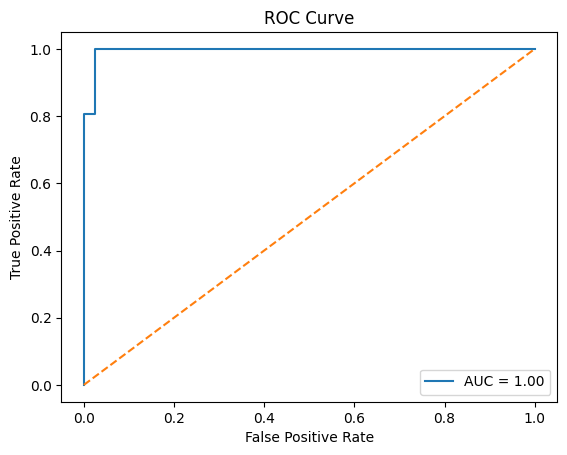

In [15]:
y_prob = model.predict_proba(X_test_scaled)[:,1]

fpr,tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test,y_prob)


plt.plot(fpr,tpr, label = f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [16]:
model_balanced = LogisticRegression(
    class_weight = "balanced",
    max_iter = 1000
)

model_balanced.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [18]:
y_pred_balanced = model_balanced.predict(X_test_scaled)

In [19]:
cm2 = confusion_matrix(y_test,y_pred_balanced)
print(cm2)

print(classification_report(y_test,y_pred_balanced))

[[41  1]
 [ 4 68]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [20]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
print(classification_report(y_test,y_pred_tree))

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

